In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("cleaned_data.csv")

In [2]:
from sklearn.preprocessing import MinMaxScaler

engagement_cols = [
'Login_Frequency',
'Session_Duration_Avg',
'Pages_Per_Session',
'Email_Open_Rate',
'Mobile_App_Usage'
]

scaler = MinMaxScaler()

df[engagement_cols] = scaler.fit_transform(
    df[engagement_cols]
)

In [3]:
df["Customer_Activity_Score"] = (
df[engagement_cols]
.mean(axis=1)
)

In [4]:
df["Revenue_Per_Purchase"] = (
df["Lifetime_Value"]/
(df["Total_Purchases"]+1)
)

In [5]:
df["Inactivity_Risk"] = (
df["Days_Since_Last_Purchase"]/
(df["Login_Frequency"]+1)
)

In [6]:
df["Customer_Friction_Index"] = (
df["Customer_Service_Calls"]+
df["Cart_Abandonment_Rate"]/10
)

In [7]:
df["Discount_Dependency"] = (
df["Discount_Usage_Rate"]*
df["Total_Purchases"]
)

In [8]:
df["Loyalty_Score"] = (
0.4*df["Membership_Years"]+
0.3*df["Login_Frequency"]+
0.3*df["Total_Purchases"]
)

In [9]:
new_features = [

'Customer_Activity_Score',

'Revenue_Per_Purchase',

'Inactivity_Risk',

'Customer_Friction_Index',

'Discount_Dependency',

'Loyalty_Score'

]

corr = df[
new_features+['Churned']
].corr()

corr["Churned"]

Customer_Activity_Score   -0.253742
Revenue_Per_Purchase       0.116967
Inactivity_Risk            0.187517
Customer_Friction_Index    0.340698
Discount_Dependency       -0.156047
Loyalty_Score             -0.153125
Churned                    1.000000
Name: Churned, dtype: float64

In [10]:
df.to_csv(
'feature_engineered.csv',
index=False
)

In [25]:
seg_cols = [
    "Customer_Activity_Score",
    "Loyalty_Score",
    "Lifetime_Value",
    "Total_Purchases",
    "Customer_Friction_Index",
    "Inactivity_Risk",
    "Days_Since_Last_Purchase",
    "Customer_Service_Calls"
]

In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = scaler.fit_transform(
df[seg_cols]
)

In [27]:
from sklearn.cluster import KMeans

In [28]:
inertia=[]

for k in range(2,9):

    km=KMeans(
        n_clusters=k,
        random_state=42
    )

    km.fit(X)

    inertia.append(
        km.inertia_
    )
    

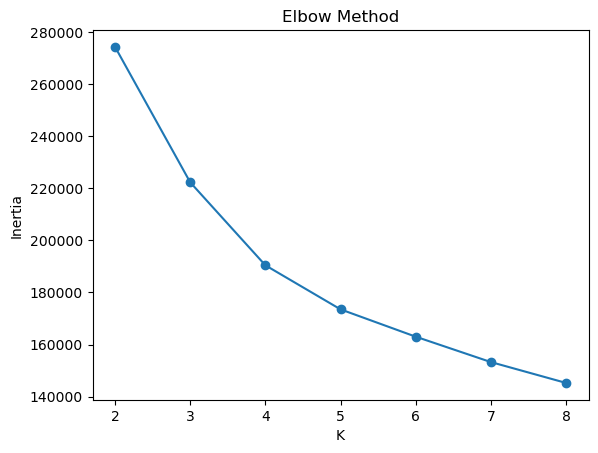

In [29]:
import matplotlib.pyplot as plt

plt.plot(
range(2,9),
inertia,
marker='o'
)

plt.xlabel("K")

plt.ylabel("Inertia")

plt.title("Elbow Method")

plt.show()

In [ ]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(X)

In [32]:
import joblib

joblib.dump(
    kmeans,
    "../models/kmeans_model.pkl"
)

['../models/kmeans_model.pkl']

In [41]:
joblib.dump(
    scaler,
    "../models/kmeans_scaler.pkl"
)

['../models/kmeans_scaler.pkl']

In [33]:
joblib.dump(
    seg_cols,
    "../models/segment_columns.pkl"
)

['../models/segment_columns.pkl']

In [34]:
cluster_summary = (
    df.groupby("Cluster")[seg_cols]
    .mean()
)

cluster_summary


,Customer_Activity_Score,Loyalty_Score,Lifetime_Value,Total_Purchases,Customer_Friction_Index,Inactivity_Risk,Days_Since_Last_Purchase,Customer_Service_Calls
Cluster,,,,,,,,
0,0.480036,8.242623,2572.765708,22.772216,7.319268,18.091670,26.123950,3.501292
1,0.264987,4.761953,1271.443206,11.688889,11.829248,74.760584,89.892251,5.831564
2,0.305118,5.252015,1435.928235,13.238046,10.273669,15.727800,19.763010,4.719936
3,0.193288,3.570308,860.678615,7.964452,14.826609,18.566480,20.968151,7.966926


In [35]:
df["Cluster"].value_counts()

Cluster
2    18735
3    16327
0     9286
1     5652
Name: count, dtype: int64

In [36]:
pd.crosstab(
    df["Cluster"],
    df["Churned"],
    normalize='index'
)

Churned,0,1
Cluster,,
0,0.797545,0.202455
1,0.549540,0.450460
2,0.807419,0.192581
3,0.607031,0.392969


In [37]:
for k in [3,5]:

    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = km.fit_predict(X)

    df[f'Cluster_{k}'] = labels

    print(f"\nK={k}")

    print(df[f'Cluster_{k}'].value_counts())

    print(
        df.groupby(
            f'Cluster_{k}'
        )[seg_cols].mean()
    )

    print(
        pd.crosstab(
            df[f'Cluster_{k}'],
            df["Churned"],
            normalize='index'
        )
    )


K=3
Cluster_3
0    26373
2    17310
1     6317
Name: count, dtype: int64
           Customer_Activity_Score  Loyalty_Score  Lifetime_Value  \
Cluster_3                                                           
0                         0.221760       4.004295     1008.826465   
1                         0.263224       4.731719     1261.353962   
2                         0.422662       7.200979     2163.926128   

           Total_Purchases  Customer_Friction_Index  Inactivity_Risk  \
Cluster_3                                                              
0                 9.327031                13.325548        16.790418   
1                11.597372                11.882075        71.959595   
2                19.430179                 8.254369        16.808716   

           Days_Since_Last_Purchase  Customer_Service_Calls  
Cluster_3                                                    
0                         19.457362                6.824062  
1                         86.4872

In [40]:
df.groupby("Cluster")[seg_cols].mean()

,Customer_Activity_Score,Loyalty_Score,Lifetime_Value,Total_Purchases,Customer_Friction_Index,Inactivity_Risk,Days_Since_Last_Purchase,Customer_Service_Calls
Cluster,,,,,,,,
0,0.480036,8.242623,2572.765708,22.772216,7.319268,18.091670,26.123950,3.501292
1,0.264987,4.761953,1271.443206,11.688889,11.829248,74.760584,89.892251,5.831564
2,0.305118,5.252015,1435.928235,13.238046,10.273669,15.727800,19.763010,4.719936
3,0.193288,3.570308,860.678615,7.964452,14.826609,18.566480,20.968151,7.966926


In [39]:
df["Cluster"].value_counts()

Cluster
2    18735
3    16327
0     9286
1     5652
Name: count, dtype: int64

In [42]:
df.groupby("Cluster")[[
    "Customer_Activity_Score",
    "Loyalty_Score",
    "Lifetime_Value",
    "Total_Purchases",
    "Customer_Friction_Index",
    "Inactivity_Risk",
    "Days_Since_Last_Purchase",
    "Customer_Service_Calls"
]].mean()

,Customer_Activity_Score,Loyalty_Score,Lifetime_Value,Total_Purchases,Customer_Friction_Index,Inactivity_Risk,Days_Since_Last_Purchase,Customer_Service_Calls
Cluster,,,,,,,,
0,0.480036,8.242623,2572.765708,22.772216,7.319268,18.091670,26.123950,3.501292
1,0.264987,4.761953,1271.443206,11.688889,11.829248,74.760584,89.892251,5.831564
2,0.305118,5.252015,1435.928235,13.238046,10.273669,15.727800,19.763010,4.719936
3,0.193288,3.570308,860.678615,7.964452,14.826609,18.566480,20.968151,7.966926


In [43]:
kmeans.cluster_centers_

array([[ 1.41689913,  1.34003185,  1.24941704,  1.37843192, -1.12925294,
        -0.23889641, -0.10893101, -0.81575202],
       [-0.24345248, -0.194913  , -0.18660128, -0.20318756,  0.12204864,
         2.14410665,  2.10015459,  0.0563144 ],
       [ 0.0682797 ,  0.02375058, -0.00343312,  0.0200405 , -0.30989245,
        -0.33812902, -0.32905804, -0.35938568],
       [-0.79645134, -0.71870255, -0.63912818, -0.73334   ,  0.95221556,
        -0.21857657, -0.28737375,  0.85407787]])